# Dane dyskretne, PMF, PDF i całkowanie numeryczne

Ten notebook porządkuje różnicę między:
- **danymi dyskretnymi**,
- **PMF** (*probability mass function*),
- **PDF** (*probability density function*),
- **sumowaniem** i **całkowaniem**.

Celem jest zbudowanie intuicji oraz pokazanie prostych obliczeń numerycznych w Pythonie.

## 1. Dane dyskretne

Dane dyskretne przyjmują konkretne, oddzielne wartości, na przykład:
- liczba dzieci,
- liczba wizyt,
- ocena 2, 3, 4, 5.

Dla takich danych naturalnym obiektem jest **PMF** (*probability mass function*), czyli funkcja przypisująca każdej wartości prawdopodobieństwo:

$$
P(X = x_i)
$$

W przypadku danych dyskretnych:
- interesuje nas prawdopodobieństwo **dokładnie tej wartości**,
- prawdopodobieństwa dla wszystkich wartości sumują się do 1:

$$
\sum_i P(X = x_i) = 1
$$

In [27]:
import numpy as np
import pandas as pd

grades = np.array([2, 3, 3, 4, 4, 4, 5, 5])

pmf = pd.Series(grades).value_counts(normalize=True).sort_index()
pmf

2    0.125
3    0.250
4    0.375
5    0.250
dtype: float64

Wynik powyżej można interpretować jako przybliżenie PMF na podstawie częstości względnych w próbce.

In [28]:
print("Suma prawdopodobieństw:", pmf.sum())
print("P(X = 4) =", pmf.loc[4])

Suma prawdopodobieństw: 1.0
P(X = 4) = 0.375


## 2. Dane ciągłe i PDF

Dane ciągłe mogą przyjmować dowolne wartości z pewnego przedziału, na przykład:
- wzrost,
- masa,
- czas,
- temperatura.

Dla takich danych używamy **PDF** (*probability density function*), czyli funkcji gęstości prawdopodobieństwa:

$$
f(x)
$$

W przypadku rozkładu ciągłego:
- prawdopodobieństwo pojedynczego punktu jest równe 0,
- znaczenie ma dopiero prawdopodobieństwo przedziału:

$$
P(a \le X \le b) = \int_a^b f(x)\,dx
$$

Całkowite pole pod wykresem PDF wynosi 1:

$$
\int_{-\infty}^{\infty} f(x)\,dx = 1
$$

## 3. Kluczowa różnica: sumowanie vs całkowanie

Dla danych dyskretnych:

$$
\sum_i P(X = x_i) = 1
$$

Dla danych ciągłych:

$$
\int f(x)\,dx = 1
$$

Najkrócej:
- **PMF** mówi o prawdopodobieństwie konkretnej wartości,
- **PDF** mówi o gęstości rozkładu,
- dla dyskretnych **sumujemy**,
- dla ciągłych **całkujemy**.

## 4. Przykład PDF: rozkład normalny

Poniżej tworzymy teoretyczny PDF rozkładu normalnego:

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right)
$$

i numerycznie sprawdzamy, czy pole pod wykresem jest równe 1.

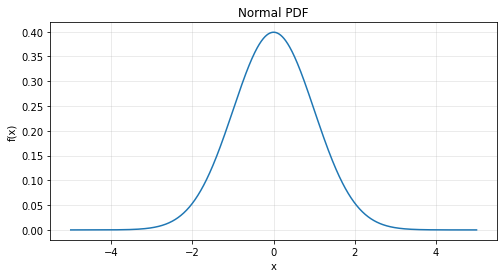

In [36]:
import matplotlib.pyplot as plt

mu = 0
sigma = 1

x = np.linspace(-5, 5, 1000)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.title('Normal PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(alpha=0.3)
plt.show()

In [37]:
area = np.trapz(pdf, x)
print("Przybliżone pole pod PDF:", area)

Przybliżone pole pod PDF: 0.9999994265727195


W praktyce nie liczymy tutaj dokładnej całki analitycznej, lecz używamy **całkowania numerycznego**.  
Wynik powinien być bardzo bliski 1.

## 5. Prawdopodobieństwo przedziału przez całkowanie numeryczne

Dla rozkładu ciągłego nie pytamy zwykle o:

$$
P(X = 1)
$$

bo to jest równe 0.

Zamiast tego pytamy o prawdopodobieństwo przedziału, na przykład:

$$
P(-1 \le X \le 1)
$$

czyli o pole pod krzywą PDF na tym przedziale.

P(-1 <= X <= 1) ≈ 0.680743868489627


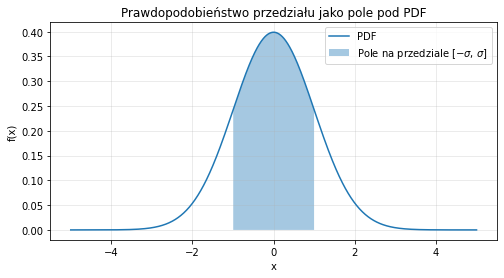

In [38]:
mask = (x >= -1) & (x <= 1)
prob_interval = np.trapz(pdf[mask], x[mask])

print("P(-1 <= X <= 1) ≈", prob_interval)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, label='PDF')
plt.fill_between(x[mask], pdf[mask], alpha=0.4, label='Pole na przedziale [$-\sigma$, $\sigma$]')
plt.title('Prawdopodobieństwo przedziału jako pole pod PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Histogram jako przybliżenie rozkładu

W praktyce zwykle nie znamy prawdziwego PDF.  
Mamy tylko próbkę danych.

Dlatego używamy:
- **histogramu**,
- albo **estymacji gęstości**,

aby przybliżyć rozkład zmiennej ciągłej.

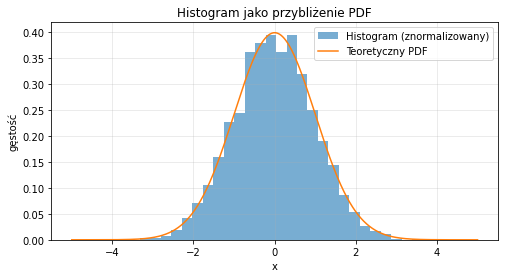

In [22]:
samples = np.random.normal(loc=0, scale=1, size=5000)

plt.figure(figsize=(8, 4))
plt.hist(samples, bins=30, density=True, alpha=0.6, label='Histogram (znormalizowany)')
plt.plot(x, pdf, label='Teoretyczny PDF')
plt.title('Histogram jako przybliżenie PDF')
plt.xlabel('x')
plt.ylabel('gęstość')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Gdy histogram jest znormalizowany (`density=True`), całkowite pole słupków jest równe 1.  
Dzięki temu można go interpretować jako przybliżenie gęstości.

## 7. Ważne rozróżnienie: dane zapisane dyskretnie vs zmienna ciągła

To, że dane w komputerze są zapisane jako skończona lista liczb, **nie oznacza jeszcze**, że sam model zmiennej musi być dyskretny.

Przykład:
- lista 5000 pomiarów wzrostu jest zapisana dyskretnie jako próbka,
- ale wzrost traktujemy jako zmienną ciągłą.

Wtedy:
- próbka jest skończona,
- ale opis statystyczny może używać PDF i całkowania.

## 7. Porównanie: udział próbki w przedziale jednej sigmy i całka PDF

Dla rozkładu normalnego wiadomo, że około 68% obserwacji powinno znajdować się
w przedziale jednej odchylenia standardowego od średniej:

$$
[\mu - \sigma, \mu + \sigma]
$$

Poniżej porównujemy dwie rzeczy:
- **udział punktów w próbce** w tym przedziale,
- **pole pod teoretycznym PDF** w tym samym zakresie.

Dzięki temu widzimy różnicę między:
- zliczaniem danych z próbki,
- a całkowaniem funkcji gęstości.

In [39]:
sample_mean = samples.mean()
sample_std = samples.std()

lower = sample_mean - sample_std
upper = sample_mean + sample_std

sample_fraction = np.mean((samples >= lower) & (samples <= upper))

mask_sigma = (x >= mu - sigma) & (x <= mu + sigma)
pdf_prob_sigma = np.trapz(pdf[mask_sigma], x[mask_sigma])

print(f"Średnia próbki: {sample_mean:.4f}")
print(f"Odchylenie standardowe próbki: {sample_std:.4f}")
print(f"Udział punktów próbki w [mean-std, mean+std]: {sample_fraction:.4f}")
print(f"Całka PDF w [mu-sigma, mu+sigma]: {pdf_prob_sigma:.4f}")

Średnia próbki: -0.0152
Odchylenie standardowe próbki: 0.9859
Udział punktów próbki w [mean-std, mean+std]: 0.6770
Całka PDF w [mu-sigma, mu+sigma]: 0.6807


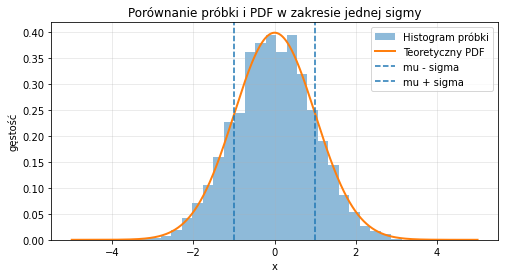

In [40]:
plt.figure(figsize=(8, 4))
plt.hist(samples, bins=30, density=True, alpha=0.5, label='Histogram próbki')
plt.plot(x, pdf, linewidth=2, label='Teoretyczny PDF')
plt.axvline(mu - sigma, linestyle='--', label='mu - sigma')
plt.axvline(mu + sigma, linestyle='--', label='mu + sigma')
plt.title('Porównanie próbki i PDF w zakresie jednej sigmy')
plt.xlabel('x')
plt.ylabel('gęstość')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

W praktyce wartości nie będą identyczne, bo:
- próbka jest losowa i skończona,
- histogram jest przybliżeniem,
- a PDF jest modelem teoretycznym.

Mimo to wyniki powinny być do siebie zbliżone.

## 8. Własna implementacja metody trapezów

Na koniec implementujemy własną funkcję całkującą metodą trapezów.
Dzięki temu można zobaczyć, co dokładnie robi `np.trapz(...)`.

Dla kolejnych punktów:
$$
(x_i, y_i), (x_{i+1}, y_{i+1})
$$
pole pojedynczego trapezu wynosi:

$$
A_i = \frac{y_i + y_{i+1}}{2} (x_{i+1} - x_i)
$$

Całka numeryczna jest sumą pól wszystkich takich trapezów.

In [25]:
def trapezoid_rule(x, y):
    total = 0.0
    for i in range(len(x) - 1):
        width = x[i + 1] - x[i]
        area = 0.5 * (y[i] + y[i + 1]) * width
        total += area
    return total

area_manual = trapezoid_rule(x, pdf)
area_numpy = np.trapz(pdf, x)

print(f"Własna metoda trapezów: {area_manual:.6f}")
print(f"NumPy np.trapz(...):    {area_numpy:.6f}")
print(f"Różnica:                {abs(area_manual - area_numpy):.6e}")

Własna metoda trapezów: 0.999999
NumPy np.trapz(...):    0.999999
Różnica:                3.330669e-16


## 9. Podsumowanie końcowe

W tym notebooku zobaczyliśmy trzy różne poziomy opisu rozkładu:

- **dane dyskretne** i częstości względne,
- **histogram** jako przybliżenie rozkładu z próbki,
- **PDF** jako ciągły model opisujący gęstość.

Widzieliśmy też dwa różne sposoby obliczania prawdopodobieństwa:
- przez **sumowanie** dla danych dyskretnych,
- przez **całkowanie numeryczne** dla gęstości ciągłej.

Na końcu porównaliśmy wyniki uzyskane z próbki i z teoretycznego PDF oraz
samodzielnie zaimplementowaliśmy metodę trapezów.

# Dodatek A. Centralne Twierdzenie Graniczne

## Graniczne twierdzenie centralne

W wielu zastosowaniach spotykamy rozkłady dyskretne lub nieregularne, ale mimo to często pojawia się rozkład normalny. Wyjaśnia to **graniczne twierdzenie centralne**.

Mówi ono, że jeśli:
- mamy wiele niezależnych zmiennych losowych,
- pochodzących z tego samego rozkładu lub z rozkładów o podobnych własnościach,
- i każda z nich ma skończoną wariancję,

to suma lub średnia tych zmiennych, po odpowiednim przeskalowaniu, ma rozkład coraz bliższy normalnemu.

### Intuicja

Każda pojedyncza zmienna może mieć rozkład:
- dyskretny,
- skośny,
- nierówny,
- nawet dość „dziwny”.

Jednak gdy dodajemy do siebie wiele niezależnych składników, ich przypadkowe odchylenia zaczynają się wzajemnie uśredniać. W efekcie rozkład sumy staje się coraz bardziej gładki i coraz lepiej przybliżany przez krzywą Gaussa.

### Co naprawdę „zmierza do normalnego”?

Nie sam pojedynczy rozkład zmiennej, lecz:
- **suma wielu zmiennych**,
- albo **średnia z wielu obserwacji**.

To bardzo ważne rozróżnienie.

### Przykład

Jeśli pojedynczy rzut kostką ma rozkład dyskretny na zbiorze:

$$
\{1,2,3,4,5,6\},
$$

to suma wielu rzutów kostką nadal jest zmienną dyskretną, ale jej histogram staje się coraz bardziej podobny do rozkładu normalnego.

### Związek z wcześniejszym notebookiem

To tłumaczy, dlaczego w praktyce:
- histogramy średnich,
- błędy pomiarowe,
- sumy wielu małych efektów losowych

bardzo często wyglądają jak rozkład normalny, nawet jeśli pojedyncze składniki nie były normalne.

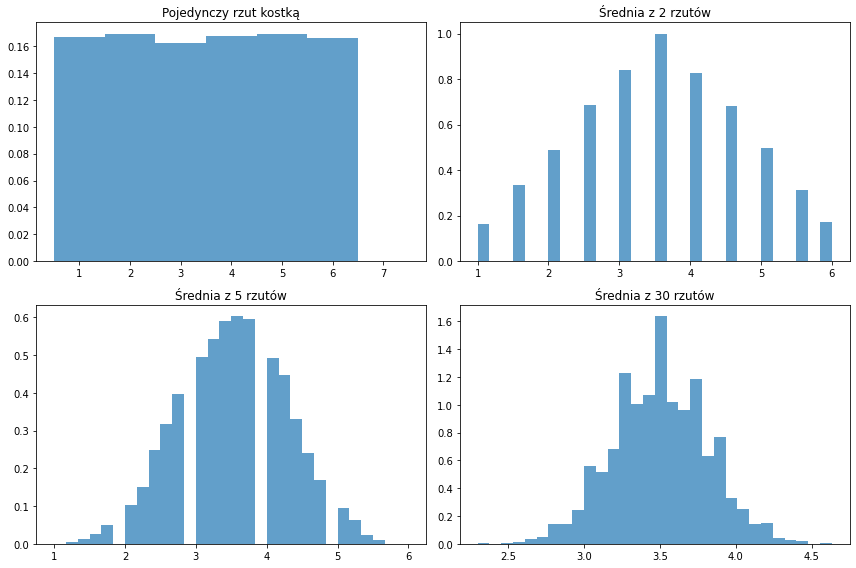

In [42]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 10000

# pojedynczy rzut kostką
single_roll = np.random.randint(1, 7, size=n_samples)

# średnia z 2, 5 i 30 rzutów
mean_2 = np.mean(np.random.randint(1, 7, size=(n_samples, 2)), axis=1)
mean_5 = np.mean(np.random.randint(1, 7, size=(n_samples, 5)), axis=1)
mean_30 = np.mean(np.random.randint(1, 7, size=(n_samples, 30)), axis=1)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(single_roll, bins=np.arange(0.5, 7.6, 1), density=True, alpha=0.7)
plt.title('Pojedynczy rzut kostką')

plt.subplot(2, 2, 2)
plt.hist(mean_2, bins=30, density=True, alpha=0.7)
plt.title('Średnia z 2 rzutów')

plt.subplot(2, 2, 3)
plt.hist(mean_5, bins=30, density=True, alpha=0.7)
plt.title('Średnia z 5 rzutów')

plt.subplot(2, 2, 4)
plt.hist(mean_30, bins=30, density=True, alpha=0.7)
plt.title('Średnia z 30 rzutów')

plt.tight_layout()
plt.show()

Widzimy, że pojedynczy rzut kostką ma wyraźnie dyskretny rozkład. Jednak rozkład średniej z wielu rzutów staje się coraz bardziej gładki i coraz bardziej przypomina rozkład normalny.

To jest właśnie intuicja stojąca za granicznym twierdzeniem centralnym.

## Graniczne twierdzenie centralne

Niech $X_1, X_2, \dots, X_n$ będą niezależnymi zmiennymi losowymi o:
- tej samej wartości oczekiwanej $\mu$,
- tej samej wariancji $\sigma^2$.

Rozważmy sumę:

$$
S_n = X_1 + X_2 + \dots + X_n
$$

oraz średnią:

$$
\bar{X}_n = \frac{1}{n} S_n
$$

Wtedy dla dużego $n$ zmienna:

$$
Z_n = \frac{S_n - n\mu}{\sigma \sqrt{n}}
$$

ma rozkład zbliżony do rozkładu normalnego:

$$
Z_n \xrightarrow{d} \mathcal{N}(0,1)
$$

---

## Wersja dla średniej

Równoważnie można zapisać:

$$
\frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1)
$$

---

## Intuicja tego wzoru

- odejmujemy średnią → „centrujemy” dane,
- dzielimy przez $\sqrt{n}$ → kontrolujemy wzrost wariancji,
- po tej normalizacji rozkład stabilizuje się i zbiega do Gaussa.

---

## Kluczowy wniosek

Dla dużych $n$:

$$
\bar{X}_n \approx \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)
$$